

---



<center><h1 style="font-size:35px; font-family: 'Calisto MT'; letter-spacing: 0.1em; background-color: RGB(128,0,128);">  </h1></center>
<center><h1 style="font-size:25px; font-family: 'Calisto MT'; letter-spacing: 0.1em; background-color: RGB(51,165,182);"> Initiation au Machine Learning 1 </h1></center>

ENSAE 2024 : ISE1 CL <right> <br> Sous la supervision de Mme Mously DIAW  <br> Réalisé par : Khadidiatou COULIBALY, Samba SOW, Mamady I BERETE, Kafando Judicaël Oscar, Ahmadou NIASS </right>



---



# 📊 Medical Cost Personal Dataset


## 🌍 Problématique globale

Dans un contexte où les dépenses de santé ne cessent d’augmenter, les compagnies d’assurance et les systèmes de santé cherchent à mieux comprendre les facteurs qui influencent les coûts médicaux. La question centrale est la suivante : **peut‑on prédire de manière fiable les charges médicales individuelles à partir de caractéristiques socio‑démographiques et comportementales ?**  
Ce problème est crucial car il permet non seulement d’anticiper les dépenses et d’ajuster les politiques tarifaires, mais aussi de mettre en évidence l’impact de variables comme l’âge, l’indice de masse corporelle, le tabagisme ou la région de résidence. L’objectif est donc de développer des modèles capables de traduire ces informations en estimations précises des coûts, afin d’améliorer la gestion des risques et la prise de décision dans le domaine de l’assurance santé.

## 📝 Description
Ce dataset contient des informations sur des bénéficiaires d’assurance santé aux États‑Unis, avec pour objectif de prédire les **coûts médicaux individuels** facturés par l’assurance.

## 📂 Structure du dataset
- **Nombre d’observations** : 1 338 lignes  
- **Nombre de variables** : 7 colonnes

### 🔑 Variables
- `age` : Âge du bénéficiaire principal  
- `sex` : Sexe du contractant (male / female)  
- `bmi` : Indice de masse corporelle (kg/m²)  
- `children` : Nombre d’enfants à charge couverts par l’assurance  
- `smoker` : Indique si le bénéficiaire est fumeur (yes / no)  
- `region` : Région de résidence aux États‑Unis (northeast, southeast, southwest, northwest)  
- `charges` : Coûts médicaux individuels facturés par l’assurance (variable cible)

## 🎯 Objectif
Construire des modèles de **régression** pour prédire les charges médicales.  

## 📌 Notes
- Les données sont **nettoyées et formatées** pour correspondre aux exemples du livre *Machine Learning with R* de Brett Lantz.  
- Licence : Open Database License (ODbL).  




---



# Table des matières

- Configuration et Import
  - Import des bibliothèques
  - Paramètres de visualisation
  - Chargement des données

- Data Overview
  - Dimensions du dataset
  - Aperçu des premières lignes
  - Types de variables
  - Séparation variables catégorielles / numériques

- Qualité des Données
  - Analyse des valeurs manquantes
  - Détection des doublons
  - Présence d’outliers
  - Tableau des outliers
  - Boxplots

- Analyse Univariée
  - Variables numériques
    - Statistiques descriptives
    - Distribution des variables numériques
  - Variables catégorielles
    - Statistiques descriptives
    - Visualisations

- Analyse Bivariée
  - Variables numériques et variable cible
    - Scatter plots
    - Heatmap de corrélations
  - Variables catégorielles et variable cible
    - Statistiques descriptives de la variable cible
    - Boxplots
    - Diagrammes en violon
  - Tests de variance
    - ANOVA (F-test)
    - Kruskal–Wallis (H-test)

- Analyse Multivariée
  - Statistiques descriptives par groupes
  - Boxplots suivant toutes les variables catégorielles
  - Pairplots suivant les variables catégorielles

- Synthèse et Conclusions
  - Insights clés
  - Recommandations pour le preprocessing





---


 <center><h1 style="font-size:35px; font-family: 'Calisto MT'; letter-spacing: 0.1em; background-color: RGB(128,0,128);">  </h1></center>
<center><h1 style="font-size:25px; font-family: 'Calisto MT'; letter-spacing: 0.1em; background-color: RGB(51,165,182);"> Explorative Data Analysis (EDA) </h1></center>


---



# Configuration et Import

## Import des bibliothèques

In [ ]:
# Manipulation de données (DataFrame, groupby, nettoyage, etc.)
import pandas as pd

# Calcul numérique (NaN, tableaux, opérations vectorisées)
import numpy as np

# Visualisation statique (graphiques classiques)
import matplotlib.pyplot as plt

# Visualisation statistique (pairplot, heatmap, boxplot/violin, etc.)
import seaborn as sns

# Gestion / filtrage des warnings (ex: warnings de matplotlib/pandas)
import warnings

# Tests statistiques (ANOVA, Kruskal, Chi2, corrélations, etc.)
from scipy.stats import pearsonr, spearmanr, f_oneway, kruskal, chi2_contingency

# Affichage "joli" des DataFrames dans Jupyter/Notebook
from IPython.display import display

# Fonction mathématique ceil (arrondi supérieur)
from math import ceil

# Sous-graphiques Plotly (grilles de figures interactives)
from plotly.subplots import make_subplots

# Plotly Express (scatter, boxplot, histogram, etc.)
import plotly.express as px


## Configuration des paramètres de visualisation

## Chargement des données

In [ ]:
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)  # adapter au chemin



---



# Data Overview

In [ ]:
# Dimensions du dataset
print(f"Dimensions du dataset: {df.shape[0]} lignes × {df.shape[1]} colonnes\n")

Dimensions du dataset: 1338 lignes × 7 colonnes



In [ ]:
# Aperçu des premières lignes
print("Aperçu des 10 premières lignes:")
df.head(10)

Aperçu des 10 premières lignes:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [ ]:
# Informations sur les colonnes
print("Informations sur les colonnes:")
df.info()

Informations sur les colonnes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
# Séparation des variables selon le type
numerical_vars = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_vars = df.select_dtypes(include=['object', 'category']).columns.tolist()



---



# Qualité des données

Dans notre cas, il n'y a pas de données manquantes.

## Présence de doublons

In [ ]:
duplicates = df.duplicated().sum()
duplicate_percentage = (duplicates / len(df) * 100)

print(f"📊 Résumé:")
print(f"   • Nombre de lignes dupliquées: {duplicates}")
print(f"   • Pourcentage: {duplicate_percentage:.2f}%")

if duplicates == 0:
    print("   ✓ Aucun doublon détecté!")
else:
    print("\n   Aperçu des lignes dupliquées:")
    print(df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist()).head(10))

print()

📊 Résumé:
   • Nombre de lignes dupliquées: 1
   • Pourcentage: 0.07%

   Aperçu des lignes dupliquées:
     age   sex    bmi  children smoker     region    charges
195   19  male  30.59         0     no  northwest  1639.5631
581   19  male  30.59         0     no  northwest  1639.5631



Nous allons supprimer la ligne dupliquée.

In [ ]:
df = df.drop_duplicates()

## Présence d'outliers

### Tableau des outliers

**Détection d’outliers avec l’IQR (règle de Tukey)**

La détection d’outliers par **IQR** (*InterQuartile Range*, ou **écart interquartile**) est une **méthode descriptive robuste**, souvent appelée **règle de Tukey** (ou *Tukey’s fences*). Elle permet d’identifier des valeurs “atypiques” **sans supposer** que la variable suit une loi normale.

Le principe est de se concentrer sur la partie centrale des données via les **quartiles** :
- **Q1** : 25ᵉ percentile  
- **Q3** : 75ᵉ percentile  
- **IQR = Q3 − Q1** : dispersion de la moitié centrale des observations

On définit ensuite deux bornes (les “barrières” de Tukey) :
- **Borne inférieure** : `Q1 − 1.5 × IQR`
- **Borne supérieure** : `Q3 + 1.5 × IQR`

Toute observation située **en dessous** de la borne inférieure ou **au-dessus** de la borne supérieure est considérée comme un **outlier potentiel**.  
Cette méthode est très utilisée en EDA (souvent via les **boxplots**) pour repérer rapidement des valeurs extrêmes, vérifier la qualité des données, et guider d’éventuels traitements (transformation log, méthodes robustes, winsorisation, etc.).


In [ ]:
## Tableau des outliers
outlier_summary = []

if len(numerical_vars) > 0:
    for var in numerical_vars:
        s = pd.to_numeric(df[var], errors="coerce").dropna()
        if s.empty:
            continue

        Q1 = s.quantile(0.25)
        Q3 = s.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = s[(s < lower_bound) | (s > upper_bound)]
        n_outliers = int(outliers.shape[0])
        n = int(s.shape[0])
        pct_outliers = (n_outliers / n) * 100

        outlier_summary.append({
            "Variable": var,
            "Q1": round(Q1, 2),
            "Q3": round(Q3, 2),
            "IQR": round(IQR, 2),
            "Limite inférieure": round(lower_bound, 2),
            "Limite supérieure": round(upper_bound, 2),
            "Nombre d'outliers": n_outliers,
            "Pourcentage (%)": round(pct_outliers, 2),
            "N (non-NaN)": n
        })

    outlier_df = pd.DataFrame(outlier_summary).sort_values("Pourcentage (%)", ascending=False)
    display(outlier_df)
else:
    print("Aucune variable numérique dans numerical_vars.")


,Variable,Q1,Q3,IQR,Limite inférieure,Limite supérieure,Nombre d'outliers,Pourcentage (%),N (non-NaN)
3,charges,4740.29,16639.91,11899.63,-13109.15,34489.35,139,10.39,1338
1,bmi,26.30,34.69,8.40,13.70,47.29,9,0.67,1338
0,age,27.00,51.00,24.00,-9.00,87.00,0,0.00,1338
2,children,0.00,2.00,2.00,-3.00,5.00,0,0.00,1338


Par la règle de Tukey, on arrive à voir que pour les variables "charges" et "bmi", 10,39% et 0,67% respectivement sont hors de la plage délimitée par les valeurs considèrées comme limite supérieur et limite inférieur; ce qui constitue potentiellement des outliers.

### Bloxplots

Ces boxplots représentent en réalité un cadre visuel de la méthode de Tukey et permet de mieux voir les outliers à travers une représentation graphique

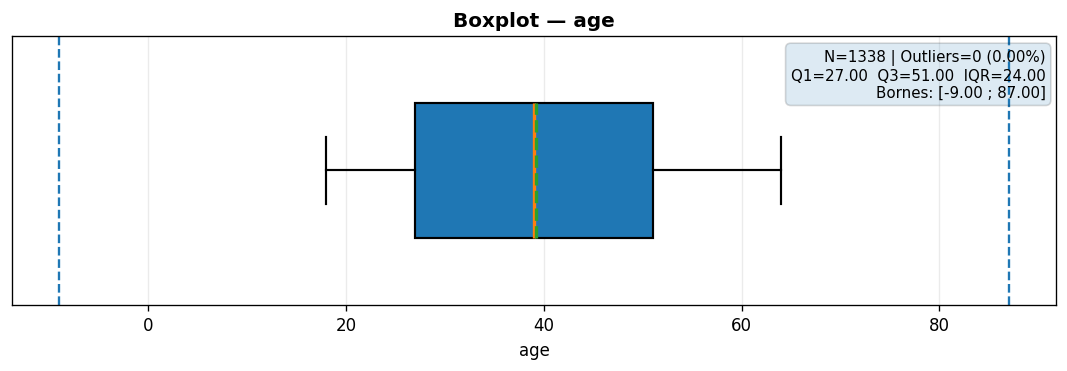

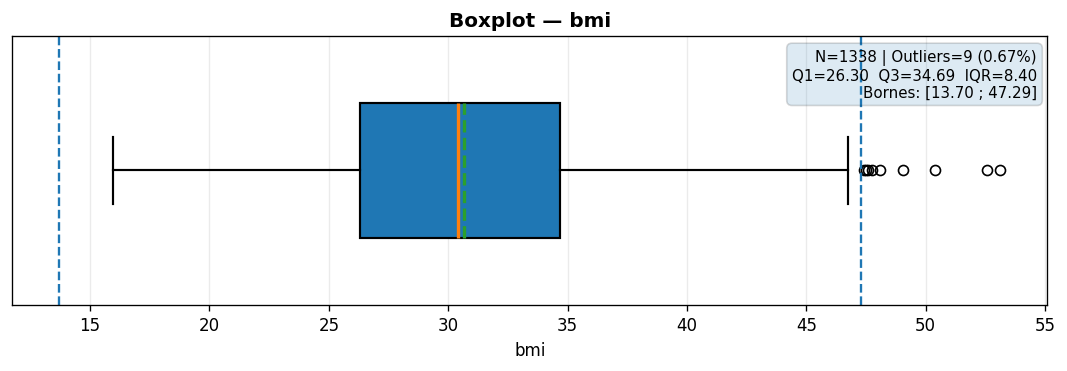

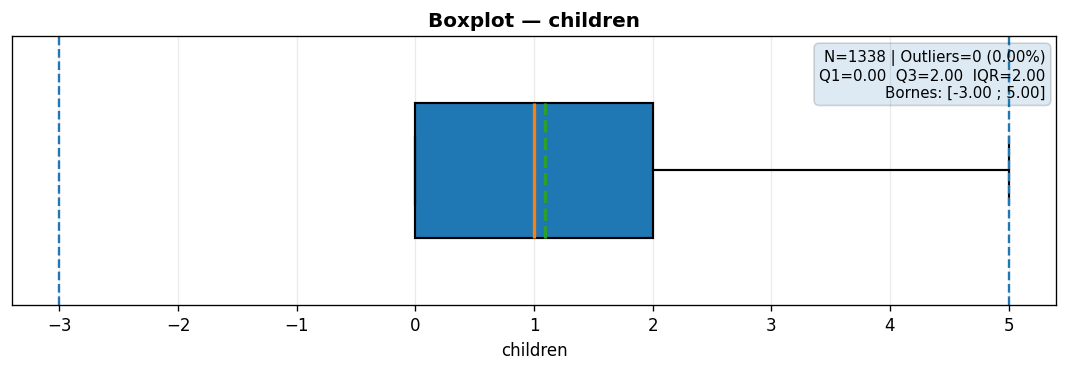

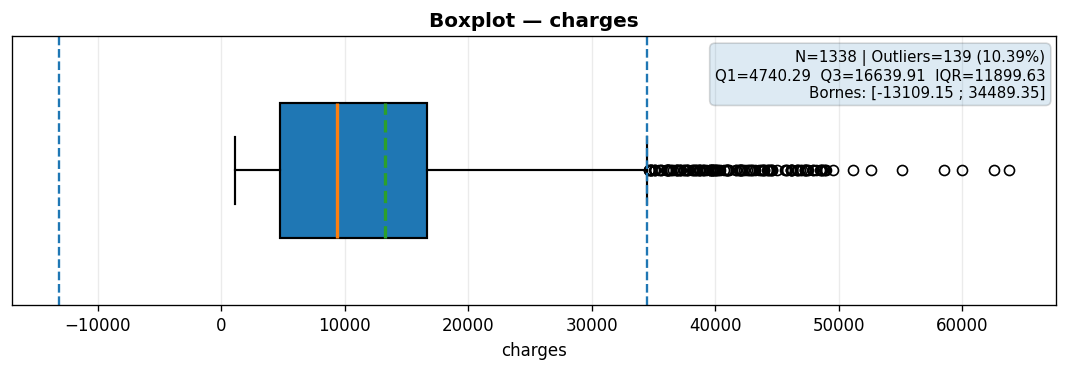

In [ ]:
# style léger et propre
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.labelsize": 10
})

if len(numerical_vars) > 0:
    for var in numerical_vars:
        s = pd.to_numeric(df[var], errors="coerce").dropna()
        if s.empty:
            continue

        Q1 = s.quantile(0.25)
        Q3 = s.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = s[(s < lower_bound) | (s > upper_bound)]
        n_outliers = int(outliers.shape[0])
        n = int(s.shape[0])
        pct_outliers = (n_outliers / n) * 100

        fig, ax = plt.subplots(figsize=(9, 3.2))

        ax.boxplot(
            s.values,
            vert=False,
            patch_artist=True,
            widths=0.5,
            showmeans=True,
            meanline=True,
            boxprops=dict(linewidth=1.3),
            whiskerprops=dict(linewidth=1.3),
            capprops=dict(linewidth=1.3),
            medianprops=dict(linewidth=2),
            meanprops=dict(linewidth=2)
        )

        # bornes IQR
        ax.axvline(lower_bound, linestyle="--", linewidth=1.4)
        ax.axvline(upper_bound, linestyle="--", linewidth=1.4)

        ax.set_title(f"Boxplot — {var}")
        ax.set_xlabel(var)
        ax.set_yticks([])

        txt = (
            f"N={n} | Outliers={n_outliers} ({pct_outliers:.2f}%)\n"
            f"Q1={Q1:.2f}  Q3={Q3:.2f}  IQR={IQR:.2f}\n"
            f"Bornes: [{lower_bound:.2f} ; {upper_bound:.2f}]"
        )
        ax.text(
            0.99, 0.95, txt,
            transform=ax.transAxes,
            ha="right", va="top",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.35", alpha=0.15)
        )

        plt.tight_layout()
        plt.show()
else:
    print("Aucune variable numérique dans numerical_vars.")




---



#  Analyse Univariée

## Variables numériques

### Statistiques descriptives

Avant l’étape de modélisation, une analyse descriptive des variables numériques est indispensable afin de mieux comprendre la structure des données. Les statistiques de base (moyenne, écart-type, minimum, maximum et quartiles) permettent d’identifier les niveaux centraux, la dispersion et la présence éventuelle de valeurs extrêmes.

En complément, des indicateurs tels que l’asymétrie (skewness), l’aplatissement (kurtosis) et le coefficient de variation apportent une vision plus fine de la distribution des variables. Cette analyse préliminaire constitue une étape clé pour orienter le choix des modèles, décider d’éventuelles transformations des variables et améliorer la robustesse et la performance des algorithmes de machine learning.

In [ ]:
if len(numerical_vars) > 0:
    print("📈 Statistiques descriptives - Variables Numériques")
    numeric_stats = df[numerical_vars].describe().round(2)
    display(numeric_stats)

    print("\n📊 Statistiques supplémentaires (Skewness / Kurtosis / CV)")
    extra_stats = pd.DataFrame({
        "Skewness": df[numerical_vars].skew().round(3),
        "Kurtosis": df[numerical_vars].kurtosis().round(3),
        "Coefficient de Variation (%)": (df[numerical_vars].std() / df[numerical_vars].mean() * 100).round(2)
    })

    # Optionnel : éviter inf si mean=0
    extra_stats["Coefficient de Variation (%)"] = extra_stats["Coefficient de Variation (%)"].replace([np.inf, -np.inf], np.nan)

    display(extra_stats)
else:
    print("Aucune variable numérique dans numerical_vars.")


📈 Statistiques descriptives - Variables Numériques


,age,bmi,children,charges
count,1337.00,1337.00,1337.00,1337.00
mean,39.22,30.66,1.10,13279.12
std,14.04,6.10,1.21,12110.36
min,18.00,15.96,0.00,1121.87
25%,27.00,26.29,0.00,4746.34
50%,39.00,30.40,1.00,9386.16
75%,51.00,34.70,2.00,16657.72
max,64.00,53.13,5.00,63770.43



📊 Statistiques supplémentaires (Skewness / Kurtosis / CV)


,Skewness,Kurtosis,Coefficient de Variation (%)
age,0.055,-1.244,35.81
bmi,0.284,-0.053,19.89
children,0.937,0.201,110.02
charges,1.515,1.604,91.20


L'analyse du second tableau montre que les variables age et bmi présentent des distributions quasi-symétriques et proches de la normalité, avec une variabilité modérée, indiquant un échantillon équilibré et bien représentatif. Ces caractéristiques permettent leur utilisation directe dans les modèles de machine learning sans transformation préalable.
En revanche, la variable charges affiche une forte asymétrie à droite et une dispersion très élevée, traduisant une hétérogénéité marquée des coûts médicaux entre individus. Cette structure déséquilibrée justifie l’application d’une transformation logarithmique avant la modélisation afin d’améliorer la stabilité et les performances prédictives des modèles.
Enfin, la variable children, de nature discrète, présente une forte dispersion relative et une asymétrie positive typique des variables de comptage. Bien que ce comportement soit attendu, il suggère un traitement spécifique, notamment sous forme catégorielle ou par regroupement en classes, pour mieux capter son effet dans les modèles.

### Distribution des variables numériques

Cette étape vise à explorer visuellement la distribution des variables numériques afin de compléter l’analyse statistique descriptive. À l’aide d’histogrammes combinés à des estimations de densité (KDE), nous examinons la forme des distributions, leur symétrie, la dispersion des données ainsi que la présence éventuelle de valeurs atypiques.

L’ajout de lignes de repère représentant la moyenne et la médiane permet d’identifier rapidement les asymétries et d’évaluer l’écart entre les mesures de tendance centrale. Cette analyse graphique constitue une étape essentielle pour valider les hypothèses de normalité, guider les choix de transformation des variables et orienter la sélection des modèles de machine learning.

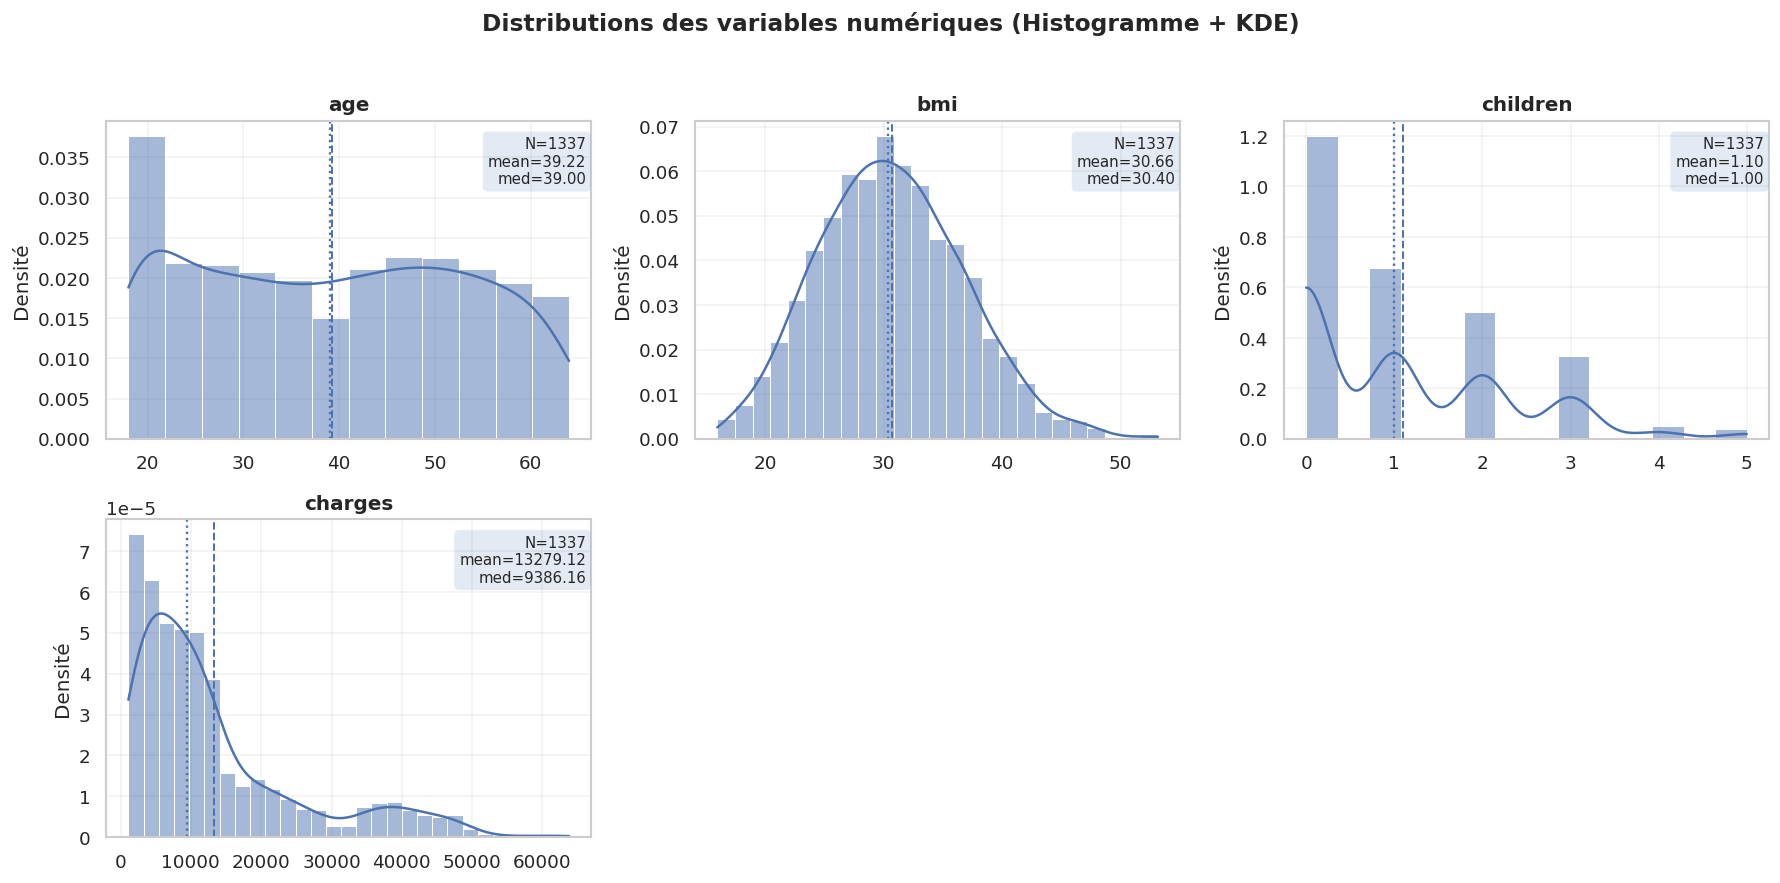

In [ ]:
sns.set_theme(style="whitegrid", context="notebook")  # rendu plus élégant

vars_ = [v for v in numerical_vars if v in df.columns]
vars_ = [v for v in vars_ if pd.to_numeric(df[v], errors="coerce").dropna().shape[0] > 0]

ncols = 3
nrows = ceil(len(vars_) / ncols) if len(vars_) > 0 else 1

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.6*nrows))
axes = np.array(axes).reshape(-1)

for i, var in enumerate(vars_):
    ax = axes[i]
    s = pd.to_numeric(df[var], errors="coerce").dropna()

    sns.histplot(
        s,
        bins="auto",
        kde=True,
        stat="density",
        ax=ax,
        edgecolor="white",
        linewidth=0.6
    )

    # Lignes de repère (moyenne / médiane)
    ax.axvline(s.mean(), linestyle="--", linewidth=1.2)
    ax.axvline(s.median(), linestyle=":", linewidth=1.4)

    ax.set_title(var)
    ax.set_xlabel("")
    ax.set_ylabel("Densité")

    ax.text(
        0.99, 0.95,
        f"N={len(s)}\nmean={s.mean():.2f}\nmed={s.median():.2f}",
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.35", alpha=0.15)
    )

# Supprime les axes vides si variables < cases
for j in range(len(vars_), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Distributions des variables numériques (Histogramme + KDE)", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


L’analyse graphique des distributions des variables numériques confirme et complète les résultats obtenus à partir des statistiques descriptives. La variable age présente une distribution globalement symétrique, avec une moyenne et une médiane très proches, traduisant une répartition équilibrée des individus et une dispersion modérée. De même, la variable bmi suit une distribution proche de la normalité, centrée autour de 30, avec une faible influence des valeurs extrêmes, ce qui permet son utilisation directe dans les modèles de machine learning sans transformation préalable.
En revanche, la variable children, de nature discrète, montre une asymétrie à droite caractéristique des variables de comptage, avec une forte concentration des observations sur les valeurs faibles. Bien que ce comportement soit attendu, il suggère un traitement spécifique, notamment sous forme catégorielle ou par regroupement de modalités, afin de mieux capturer son effet dans la modélisation.
Enfin, la variable charges se distingue par une forte asymétrie positive, matérialisée par un écart important entre la moyenne et la médiane et par la présence de valeurs extrêmes élevées. Cette structure très déséquilibrée traduit une hétérogénéité marquée des coûts médicaux entre individus. Par conséquent, une transformation logarithmique de cette variable apparaît nécessaire afin de stabiliser la variance, rapprocher la distribution de la normalité et améliorer les performances et la robustesse des modèles prédictifs.

## Variables catégorielles

### Statistiques descriptives

In [ ]:
if len(categorical_vars) > 0:
    cat_summary = []

    for var in categorical_vars:
        if var not in df.columns:
            continue

        s = df[var]
        n_total = len(df)

        n_cat = s.nunique(dropna=True)
        mode_val = s.mode(dropna=True)
        top_cat = mode_val.iloc[0] if not mode_val.empty else np.nan

        vc = s.value_counts(dropna=True)
        top_freq = int(vc.iloc[0]) if not vc.empty else 0
        top_pct = round((top_freq / n_total) * 100, 2) if n_total > 0 else 0

        cat_summary.append({
            "Variable": var,
            "Nombre de catégories": int(n_cat),
            "Catégorie la plus fréquente": top_cat,
            "Fréquence max": top_freq,
            "Pourcentage max (%)": top_pct,
            "N manquants": int(s.isna().sum()),
            "% manquants": round((s.isna().mean() * 100), 2)
        })

    cat_df = pd.DataFrame(cat_summary).sort_values("Pourcentage max (%)", ascending=False)
    display(cat_df)
else:
    print("Aucune variable catégorielle dans categorical_vars.")


,Variable,Nombre de catégories,Catégorie la plus fréquente,Fréquence max,Pourcentage max (%),N manquants,% manquants
1,smoker,2,no,1063,79.51,0,0.0
0,sex,2,male,675,50.49,0,0.0
2,region,4,southeast,364,27.23,0,0.0


L’analyse des variables catégorielles met en évidence des distributions globalement équilibrées et exploitables pour la modélisation. La variable smoker comporte deux modalités, avec une forte dominance des non-fumeurs (environ 79,5 %), ce qui suggère un déséquilibre marqué mais informatif, cette variable étant potentiellement très discriminante pour expliquer les charges médicales. La variable sex est presque parfaitement équilibrée entre hommes et femmes (50,5 % d’hommes), ce qui limite les biais liés à la représentation d’un sexe dans les modèles. Enfin, la variable region, composée de quatre catégories, présente une répartition relativement homogène, la modalité la plus fréquente ne représentant qu’environ 27 % des observations. L’absence totale de valeurs manquantes pour l’ensemble des variables catégorielles constitue un atout supplémentaire pour la qualité des données et permet leur intégration directe dans les modèles après encodage approprié.

### Visualisations

Afin de compléter l’analyse descriptive des variables catégorielles, une exploration visuelle de leur répartition est réalisée à l’aide de diagrammes circulaires (donut charts). Cette représentation permet d’identifier rapidement les catégories dominantes, d’évaluer le degré d’équilibre entre les modalités et de détecter d’éventuels déséquilibres susceptibles d’influencer la modélisation.
L’affichage des proportions facilite l’interprétation des distributions et oriente les choix d’encodage et de traitement des variables catégorielles lors des étapes suivantes du processus de machine learning.

In [ ]:

# Paramètres
INCLUDE_NA = True         # inclure les NaN comme catégorie "Manquant"
MIN_PCT_FOR_LABEL = 3     # afficher le texte seulement si >= 3%

for var in categorical_vars:
    if var not in df.columns:
        continue

    s = df[var]
    if INCLUDE_NA:
        s = s.astype("object").fillna("Manquant")
    else:
        s = s.dropna()

    counts = s.value_counts(dropna=False)
    if counts.empty:
        continue

    # AUCUN regroupement : toutes les modalités
    pie_df = counts.reset_index()
    pie_df.columns = [var, "Effectif"]
    pie_df["%"] = (pie_df["Effectif"] / pie_df["Effectif"].sum() * 100).round(2)

    fig = px.pie(
        pie_df,
        names=var,
        values="Effectif",
        hole=0.45,  # donut = plus moderne
        template="plotly_white",
        title=f"Répartition — {var}"
    )

    # Labels (on garde hover complet)
    fig.update_traces(
        textinfo="percent+label",
        textposition="outside",
        pull=[0.03] * len(pie_df),
        sort=False
    )

    # Masquer les labels trop petits (optionnel) pour garder un visuel clean
    fig.update_traces(
        text=[
            f"{row[var]} ({row['%']}%)" if row["%"] >= MIN_PCT_FOR_LABEL else ""
            for _, row in pie_df.iterrows()
        ],
        hovertemplate=f"<b>{var}</b>: %{{label}}<br>Effectif: %{{value}}<br>Part: %{{percent}}<extra></extra>"
    )

    fig.update_layout(
        title_x=0.5,
        legend_title_text="",
        height=560
    )

    fig.show()


La visualisation des variables catégorielles met en évidence des répartitions globalement équilibrées et informatives pour la modélisation. La variable sex présente une distribution quasi parfaitement équilibrée entre hommes (≈50,5 %) et femmes (≈49,5 %), ce qui limite les biais liés à la représentation d’un groupe. La variable smoker est en revanche fortement déséquilibrée, avec une majorité de non-fumeurs (≈79,5 %) contre environ 20,5 % de fumeurs, suggérant un facteur potentiellement très discriminant pour l’analyse des charges médicales. Enfin, la variable region affiche une répartition relativement homogène entre les quatre modalités, aucune ne dépassant 30 %, ce qui indique une bonne couverture géographique de l’échantillon et réduit le risque de biais régional dans les modèles.



---



# Analyse Bivariée

## Variables numériques et variable cible

### Scatter plots

text

In [ ]:
target = "charges"
for x in numerical_vars:
    if x == target or x not in df.columns:
        continue

    tmp = df[[x, target]].copy()
    tmp[x] = pd.to_numeric(tmp[x], errors="coerce")
    tmp[target] = pd.to_numeric(tmp[target], errors="coerce")
    tmp = tmp.dropna(subset=[x, target])

    fig = px.scatter(
        tmp,
        x=x, y=target,
        template="plotly_white",
        title=f"{target} vs {x}"
    )
    fig.update_traces(marker=dict(opacity=0.6))
    fig.update_layout(title_x=0.5, height=520)
    fig.show()


L’analyse des relations entre les charges médicales et les variables explicatives révéle plusieurs comportements distincts. La relation entre charges et âge montre une tendance globalement croissante : les charges augmentent avec l’âge, bien que la dispersion soit importante, indiquant que l’âge seul n’explique pas entièrement le niveau des dépenses.
La relation entre charges et IMC (BMI) révèle une structure non linéaire marquée. Si les charges restent relativement faibles pour des valeurs modérées de l’IMC, on observe une concentration de charges élevées pour des niveaux d’IMC plus importants, traduisant un risque accru de coûts médicaux élevés chez les individus en surpoids ou obèses. La forte dispersion confirme une interaction probable avec d’autres variables, notamment le statut de fumeur.
Enfin, la relation entre charges et nombre d’enfants ne fait apparaître aucune tendance claire. Les charges restent très dispersées quel que soit le nombre d’enfants, ce qui suggère un impact limité et indirect de cette variable sur les dépenses médicales. Cette observation renforce l’idée que children doit être traitée comme une variable secondaire ou catégorielle dans la modélisation.

Dans l’ensemble, ces visualisations confirment la complexité et la non-linéarité des relations entre les variables explicatives et les charges médicales, justifiant le recours à des modèles de machine learning non linéaires pour capturer ces interactions de manière plus efficace.

### Heatmap de corrélations

Afin d’examiner les relations linéaires entre les variables numériques, une matrice de corrélation de Pearson est calculée et représentée sous forme de heatmap. Cette visualisation permet d’identifier rapidement les variables fortement corrélées, de détecter d’éventuelles redondances d’information et d’anticiper les risques de multicolinéarité. L’analyse des corrélations constitue une étape essentielle pour orienter la sélection des variables et le choix des modèles lors de la phase de modélisation en machine learning.

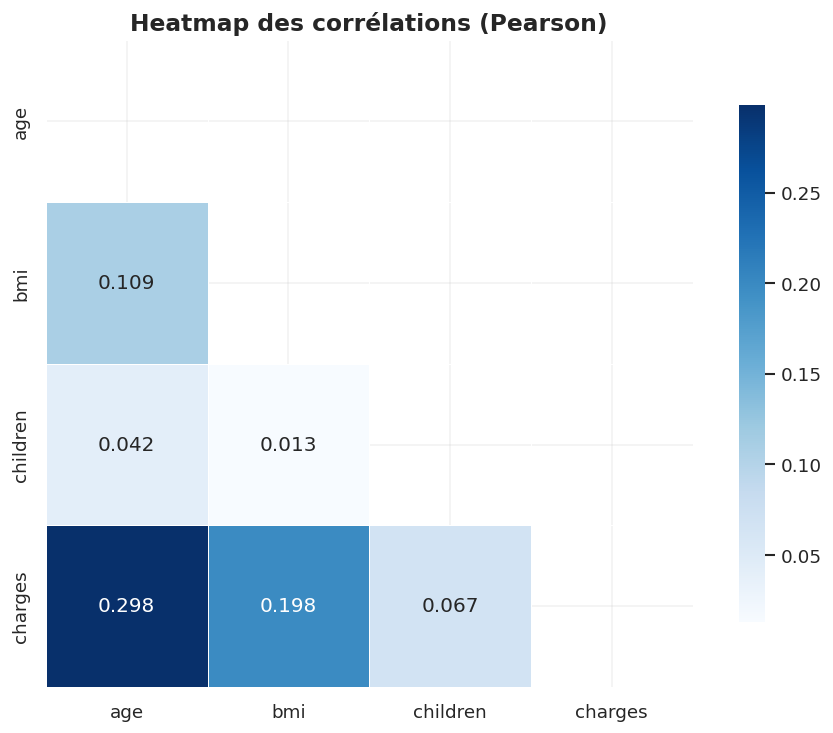

In [ ]:
tmp = df[numerical_vars].copy()
corr = tmp.corr(method="pearson")

mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True

plt.figure(figsize=(10, 7))
sns.heatmap(corr, cmap='Blues', annot=True, square=True,
            fmt='.3f', mask=mask, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title("Heatmap des corrélations (Pearson)", fontsize=14)
plt.show()


L’analyse de la matrice de corrélation met en évidence des relations linéaires globalement faibles à modérées entre les variables numériques. La variable charges présente la corrélation la plus élevée avec l’âge (r ≈ 0,30), indiquant une relation linéaire positive modérée : les charges médicales tendent à augmenter avec l’âge, sans pour autant être expliquées uniquement par celui-ci. Une corrélation positive plus faible est également observée entre charges et IMC (BMI) (r ≈ 0,20), suggérant un effet contributif mais limité de l’IMC sur les dépenses médicales.

En revanche, la corrélation entre charges et nombre d’enfants est très faible (r ≈ 0,07), ce qui confirme que cette variable a un impact direct limité sur les charges médicales. Les corrélations entre les variables explicatives elles-mêmes sont également faibles, notamment entre âge, IMC et enfants, ce qui indique une faible multicolinéarité et constitue un point favorable pour la modélisation.

## Variables catégorielles et variable cible

### Statistiques descriptives de la variable cible suivant les vaiables catégorielles

In [ ]:
all_stats = []

for var in categorical_vars:
    if var not in df.columns or target not in df.columns:
        continue

    tmp = df[[var, target]].copy()
    if tmp.empty:
        continue

    g = tmp.groupby(var)[target]

    stats = g.agg(
        N="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
        max="max"
    ).reset_index()

    stats["IQR"] = stats["q3"] - stats["q1"]
    stats["CV (%)"] = (stats["std"] / stats["mean"] * 100).replace([np.inf, -np.inf], np.nan)

    stats.insert(0, "Variable", var)

    # Arrondis propres
    for c in ["mean","median","std","min","q1","q3","max","IQR","CV (%)"]:
        stats[c] = stats[c].round(2)

    # Tri : catégories avec médiane la plus grande en haut (pratique)
    stats = stats.sort_values("median", ascending=False)

    all_stats.append(stats)

if len(all_stats) > 0:
    target_by_cat_stats = pd.concat(all_stats, ignore_index=True)
    display(target_by_cat_stats)
else:
    print("Aucune statistique à afficher (vérifie categorical_vars et/ou charges).")


,Variable,sex,N,mean,median,std,min,q1,q3,max,IQR,CV (%),smoker,region
0,sex,female,662,12569.58,9412.96,11128.70,1607.51,4885.16,14454.69,63770.43,9569.53,88.54,NaN,NaN
1,sex,male,675,13975.00,9377.90,12971.96,1121.87,4654.02,19006.69,62592.87,14352.66,92.82,NaN,NaN
2,smoker,NaN,274,32050.23,34456.35,11541.55,12829.46,20826.24,41019.21,63770.43,20192.96,36.01,yes,NaN
3,smoker,NaN,1063,8440.66,7345.73,5992.97,1121.87,3988.88,11363.02,36910.61,7374.14,71.00,no,NaN
4,region,NaN,324,13406.38,10057.65,11255.80,1694.80,5194.32,16687.36,58571.07,11493.04,83.96,NaN,northeast
5,region,NaN,364,14735.41,9294.13,13971.10,1121.87,4440.89,19526.29,63770.43,15085.40,94.81,NaN,southeast
6,region,NaN,324,12450.84,8976.98,11073.13,1621.34,4733.64,14788.75,60021.40,10055.11,88.93,NaN,northwest
7,region,NaN,325,12346.94,8798.59,11557.18,1241.56,4751.07,13462.52,52590.83,8711.45,93.60,NaN,southwest


L’analyse des charges médicales moyennes selon les différentes catégories met en évidence des écarts significatifs entre les groupes. En moyenne, les hommes présentent des charges légèrement plus élevées que les femmes, bien que les médianes restent proches, indiquant une distribution globalement asymétrique pour les deux groupes.

Le contraste le plus marqué concerne le statut de fumeur : les fumeurs affichent des charges moyennes nettement supérieures à celles des non-fumeurs, ce qui souligne l’influence déterminante de ce facteur sur les dépenses médicales.

Enfin, selon la région, les charges moyennes varient modérément d’un groupe à l’autre, sans différence extrême, suggérant un effet régional limité comparé à d’autres variables explicatives.

### Boxplots suivant les variables catégorielles

In [ ]:
for var in categorical_vars:
    if var not in df.columns or target not in df.columns:
        continue

    tmp = df[[var, target]].copy()
    tmp[var] = tmp[var].astype("object").fillna("Manquant")

    # Enlève les NaN de la cible
    tmp[target] = pd.to_numeric(tmp[target], errors="coerce")
    tmp = tmp.dropna(subset=[target])

    if tmp.empty:
        continue

    # Ordonner les catégories par médiane de charges (super lisible)
    order = (
        tmp.groupby(var)[target]
        .median()
        .sort_values(ascending=True)
        .index.tolist()
    )

    fig = px.box(
        tmp,
        x=var,
        y=target,
        category_orders={var: order},
        points="outliers",
        template="plotly_white",
        title=f"Boxplots — {target} selon {var}"
    )

    fig.update_layout(
        title_x=0.5,
        xaxis_title=var,
        yaxis_title=target,
        height=520
    )
    fig.update_xaxes(tickangle=-25)
    fig.show()


Dans la continuité de l’analyse précédente, les boxplots permettent d’affiner la compréhension de l’influence des variables catégorielles sur les charges médicales. Les différences observées selon le sexe restent limitées : les niveaux centraux sont proches et seules de légères variations de dispersion apparaissent, ce qui confirme un effet relativement faible de cette variable.

En revanche, le statut de fumeur se distingue clairement comme un facteur déterminant. Les charges associées aux fumeurs sont nettement plus élevées et beaucoup plus dispersées, avec de nombreux cas extrêmes, renforçant l’idée d’un impact majeur de cette variable sur la structure des dépenses médicales.

Enfin, l’analyse par région met en évidence des distributions globalement similaires, malgré une dispersion légèrement plus marquée dans certaines zones. Cet effet régional demeure toutefois secondaire comparé à celui du tabagisme.

Ces observations consolident les conclusions issues des analyses précédentes et confirment l’intérêt d’intégrer des modèles capables de capturer des effets différenciés et potentiellement non linéaires dans la phase de modélisation.

### Diagrammes en violon suivant les variables catégorielles

Les diagrammes en violon combinent la richesse d'un histogramme avec la clarté d'un boxplot pour révéler la distribution complète de notre variable cible charges selon chaque variable catégorielle. Contrairement aux boxplots traditionnels qui ne montrent que les quartiles, les violons visualisent la densité de probabilité à chaque niveau de valeur : plus le violon est large, plus il y a d'observations à ce niveau.
Chaque violon intègre un mini-boxplot (médiane, quartiles) et affiche les valeurs aberrantes sous forme de points individuels. Les catégories sont ordonnées par médiane croissante pour faciliter la comparaison visuelle. Cette représentation permet d'identifier rapidement les distributions asymétriques, les sous-populations distinctes (distributions bimodales), et l'amplitude de variation des charges au sein de chaque catégorie. Elle est particulièrement utile pour détecter si certains groupes présentent des profils de coûts radicalement différents, information cruciale pour la modélisation prédictive.

In [ ]:
for var in categorical_vars:
    if var not in df.columns or target not in df.columns:
        continue

    tmp = df[[var, target]].copy()
    tmp[var] = tmp[var].astype("object").fillna("Manquant")

    tmp[target] = pd.to_numeric(tmp[target], errors="coerce")
    tmp = tmp.dropna(subset=[target])

    if tmp.empty:
        continue

    # Ordre par médiane (cohérent avec boxplot)
    order = (
        tmp.groupby(var)[target]
        .median()
        .sort_values(ascending=True)
        .index.tolist()
    )

    fig = px.violin(
        tmp,
        x=var,
        y=target,
        category_orders={var: order},
        box=True,          # mini boxplot dans le violon
        points="outliers", # montre les points extrêmes
        template="plotly_white",
        title=f"Violons — {target} selon {var}"
    )

    fig.update_layout(
        title_x=0.5,
        xaxis_title=var,
        yaxis_title=target,
        height=520
    )
    fig.update_xaxes(tickangle=-25)
    fig.show()


Les diagrammes en violon permettent d’aller au-delà des boxplots en mettant en évidence la densité des charges médicales au sein de chaque catégorie. Selon le sexe, les distributions restent proches, avec des formes similaires et des niveaux centraux comparables, confirmant que l’effet du sexe sur les charges est relativement modéré.

En revanche, le statut de fumeur se distingue nettement : la distribution des charges chez les fumeurs est décalée vers des valeurs beaucoup plus élevées, avec une densité importante dans les niveaux de coûts élevés. Cette différence de forme et de position renforce le rôle central du tabagisme dans l’explication des charges médicales.

Enfin, l’analyse par région montre des distributions largement superposées, malgré quelques variations de dispersion et de densité. Ces écarts restent secondaires et suggèrent que l’influence de la région est limitée comparée à celle d’autres variables explicatives.

Dans l’ensemble, ces visualisations confirment les conclusions précédentes et soulignent la nécessité de modèles capables de capturer des distributions asymétriques et des effets hétérogènes, en particulier pour la variable cible charges.

## Tests de variance

### ANOVA (F-test)

L’**ANOVA à un facteur** (analyse de variance) teste si la **moyenne** de la variable cible (ici `charges`) est la même dans **toutes** les catégories d’une variable qualitative. L’hypothèse nulle est : *toutes les moyennes sont égales* ; si la *p-value* est petite, on conclut qu’au moins une catégorie a une moyenne différente. On l’utilise surtout quand la cible est **quantitative**, la variable explicative est **catégorielle**, et que les conditions sont raisonnablement satisfaites : **indépendance** des observations, **normalité des résidus** (ou au moins distributions pas trop éloignées de la normale dans chaque groupe, surtout si les effectifs sont corrects) et **homogénéité des variances** entre groupes (souvent vérifiée via Levene). En cas de variances très différentes, on préfère souvent **Welch-ANOVA** ou un test non paramétrique.


### Kruskal–Wallis (H-test)

Le **test de Kruskal–Wallis** est l’alternative **non paramétrique** à l’ANOVA : il compare les groupes en se basant sur les **rangs** plutôt que sur les valeurs, ce qui le rend plus robuste quand la cible est **asymétrique**, contient des **outliers**, ou quand l’hypothèse de normalité est discutable. L’hypothèse nulle est que les groupes proviennent de distributions “semblables” (souvent interprété comme “mêmes médianes” quand les formes de distribution sont comparables). On l’utilise donc quand `charges` n’est pas bien modélisable par une normale, quand les effectifs sont faibles, ou quand les outliers dominent. Attention : si les distributions ont des **formes très différentes** (pas seulement un décalage), Kruskal–Wallis peut détecter une différence sans que ce soit uniquement une différence de médiane.

### À retenir (choix rapide)

* **ANOVA** : bonne option si tu peux accepter les hypothèses (ou si les effectifs sont grands et les variances pas trop différentes).
* **Kruskal–Wallis** : option robuste si les distributions sont non normales / très asymétriques / avec outliers.
* Dans les deux cas, si le test est significatif, il ne dit pas *quels groupes* diffèrent : il faut un **post-hoc** (Tukey après ANOVA, ou Dunn après Kruskal–Wallis).


In [ ]:
MIN_GROUP_SIZE = 2  # seuil minimal par modalité

def sig_label(p):
    if pd.isna(p):
        return "NA"
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

if len(categorical_vars) > 0 and target in df.columns:

    rows = []

    for cat_var in categorical_vars:
        if cat_var not in df.columns:
            continue

        tmp = df[[cat_var, target]].copy()
        tmp[cat_var] = tmp[cat_var].astype("object").fillna("Manquant")
        tmp[target] = pd.to_numeric(tmp[target], errors="coerce")
        tmp = tmp.dropna(subset=[target])

        if tmp.empty:
            continue

        groups = []
        for level, g in tmp.groupby(cat_var)[target]:
            g = g.dropna()
            if len(g) >= MIN_GROUP_SIZE:
                groups.append(g.values)

        k = len(groups)
        if k < 2:
            rows.append({
                "Variable": cat_var,
                "Nb_groupes": k,
                "ANOVA_F": np.nan, "ANOVA_p": np.nan, "ANOVA_sig": "NA", "ANOVA_rejet_H0": "NA",
                "KW_H": np.nan, "KW_p": np.nan, "KW_sig": "NA", "KW_rejet_H0": "NA"
            })
            continue

        # ANOVA
        try:
            f_stat, p_anova = stats.f_oneway(*groups)
        except Exception:
            f_stat, p_anova = np.nan, np.nan

        # Kruskal
        try:
            h_stat, p_kw = stats.kruskal(*groups)
        except Exception:
            h_stat, p_kw = np.nan, np.nan

        rows.append({
            "Variable": cat_var,
            "Nb_groupes": k,

            "ANOVA_F": f_stat,
            "ANOVA_p": p_anova,
            "ANOVA_sig": sig_label(p_anova),
            "ANOVA_rejet_H0": "Oui" if pd.notna(p_anova) and p_anova < 0.05 else ("Non" if pd.notna(p_anova) else "NA"),

            "KW_H": h_stat,
            "KW_p": p_kw,
            "KW_sig": sig_label(p_kw),
            "KW_rejet_H0": "Oui" if pd.notna(p_kw) and p_kw < 0.05 else ("Non" if pd.notna(p_kw) else "NA"),
        })

    results_df = pd.DataFrame(rows)

    # Format propre (sans couleurs)
    if not results_df.empty:
        results_df["ANOVA_F"] = results_df["ANOVA_F"].round(4)
        results_df["KW_H"] = results_df["KW_H"].round(4)

        # p-values en format scientifique lisible
        results_df["ANOVA_p"] = results_df["ANOVA_p"].map(lambda x: f"{x:.4e}" if pd.notna(x) else None)
        results_df["KW_p"] = results_df["KW_p"].map(lambda x: f"{x:.4e}" if pd.notna(x) else None)

        # Tri “le plus significatif d'abord” (sur KW en priorité, puis ANOVA)
        # (on trie sur les p-values numériques -> on crée des colonnes temporaires)
        tmp_sort = results_df.copy()
        tmp_sort["_ANOVA_p_num"] = pd.to_numeric(tmp_sort["ANOVA_p"], errors="coerce")
        tmp_sort["_KW_p_num"] = pd.to_numeric(tmp_sort["KW_p"], errors="coerce")
        tmp_sort = tmp_sort.sort_values(["_KW_p_num", "_ANOVA_p_num"], ascending=True).drop(columns=["_ANOVA_p_num", "_KW_p_num"])

        display(tmp_sort)
    else:
        print("Aucun résultat à afficher (vérifie categorical_vars et/ou charges).")

else:
    print("Aucune variable catégorielle ou la cible n'existe pas dans df.")


,Variable,Nb_groupes,ANOVA_F,ANOVA_p,ANOVA_sig,ANOVA_rejet_H0,KW_H,KW_p,KW_sig,KW_rejet_H0
1,smoker,2,2177.6149,8.2714e-283,***,Oui,588.5197,5.2590e-130,***,Oui
2,region,4,2.9696,3.0893e-02,*,Oui,4.7342,1.9233e-01,ns,Non
0,sex,2,4.3997,3.6133e-02,*,Oui,0.1204,7.2860e-01,ns,Non


Conclusion : Les résultats des tests confirment des différences significatives entre certains groupes pour la variable cible charges. Le statut de fumeur ressort très nettement comme un facteur discriminant majeur : l’ANOVA comme le test de Kruskal-Wallis sont hautement significatifs, conduisant au rejet clair de l’hypothèse d’égalité des groupes.

Pour la variable sexe, l’ANOVA indique une différence significative entre les groupes, tandis que le test de Kruskal-Wallis ne confirme pas ce résultat. Cette divergence suggère un effet faible et sensible aux hypothèses de normalité, indiquant que l’influence du sexe sur les charges reste limitée.

Enfin, concernant la région, l’ANOVA met en évidence une différence statistiquement significative, mais celle-ci n’est pas validée par le test non paramétrique. Cela suggère que les écarts observés entre régions sont modestes et peu robustes.

Dans l’ensemble, ces tests renforcent l’idée que le statut de fumeur est le facteur explicatif le plus déterminant des charges médicales, tandis que l’effet du sexe et de la région demeure secondaire.

# Analyse Multivariée

## Statistiques descriptives par groupes

Après l’analyse graphique et statistique des relations entre la variable cible et les variables explicatives, nous complétons l’exploration par une analyse descriptive groupée.
Cette étape consiste à étudier le comportement des variables numériques en fonction de chaque variable catégorielle, à travers des statistiques clés telles que la moyenne, la médiane et l’écart-type.

L’objectif est de quantifier les différences observées visuellement, d’évaluer la dispersion au sein de chaque groupe et de mieux comprendre la variabilité des charges médicales selon les différentes catégories.
Cette analyse permet ainsi de renforcer l’interprétation des résultats précédents et de préparer la phase de modélisation en identifiant les variables les plus discriminantes.

In [ ]:
df = df.loc[:, ~df.columns.duplicated()].copy()

if len(categorical_vars) >= 1 and len(numerical_vars) >= 1:

    tmp = df.copy()

    # Convertir numériques une seule fois
    for c in numerical_vars:
        if c in tmp.columns:
            tmp[c] = pd.to_numeric(tmp[c], errors="coerce")

    for cat_var in categorical_vars:
        if cat_var not in tmp.columns:
            continue

        tmp_cat = tmp.copy()
        tmp_cat[cat_var] = tmp_cat[cat_var].astype("object").fillna("Manquant")

        print(f"\n{'='*80}")
        print(f"📊 Statistiques groupées (mean/median/std) — par {cat_var}")
        print(f"Nombre de catégories : {tmp_cat[cat_var].nunique(dropna=False)}")
        print(f"{'='*80}\n")

        grouped_stats = (
            tmp_cat.groupby(cat_var)[numerical_vars]
                   .agg(["mean", "median", "std"])
                   .round(2)
        )

        display(grouped_stats)

else:
    print("⚠️ Pas assez de variables catégorielles/numériques.")



📊 Statistiques groupées (mean/median/std) — par sex
Nombre de catégories : 2



age                  bmi              children               \
         mean median    std   mean median   std     mean median   std   
sex                                                                     
female  39.50   40.0  14.05  30.38  30.11  6.05     1.07    1.0  1.19   
male    38.92   39.0  14.05  30.94  30.69  6.14     1.12    1.0  1.22   

         charges                     
            mean   median       std  
sex                                  
female  12569.58  9412.96  11128.70  
male    13956.75  9369.62  12971.03


📊 Statistiques groupées (mean/median/std) — par smoker
Nombre de catégories : 2



age                  bmi              children               \
         mean median    std   mean median   std     mean median   std   
smoker                                                                  
no      39.39   40.0  14.08  30.65  30.35  6.04     1.09    1.0  1.22   
yes     38.51   38.0  13.92  30.71  30.45  6.32     1.11    1.0  1.16   

         charges                      
            mean    median       std  
smoker                                
no       8434.27   7345.41   5993.78  
yes     32050.23  34456.35  11541.55


📊 Statistiques groupées (mean/median/std) — par region
Nombre de catégories : 4



age                  bmi              children               \
            mean median    std   mean median   std     mean median   std   
region                                                                     
northeast  39.27   39.5  14.07  29.17  28.88  5.94     1.05    1.0  1.20   
northwest  39.20   39.0  14.05  29.20  28.88  5.14     1.15    1.0  1.17   
southeast  38.94   39.0  14.16  33.36  33.33  6.48     1.05    1.0  1.18   
southwest  39.46   39.0  13.96  30.60  30.30  5.69     1.14    1.0  1.28   

            charges                      
               mean    median       std  
region                                   
northeast  13406.38  10057.65  11255.80  
northwest  12417.58   8965.80  11072.28  
southeast  14735.41   9294.13  13971.10  
southwest  12346.94   8798.59  11557.18

L’analyse des statistiques groupées met en évidence des différences marquées des charges médicales selon certaines variables catégorielles.
Selon le sexe, les hommes présentent en moyenne des charges plus élevées que les femmes (≈ 13 957 contre 12 570), avec une dispersion plus importante, bien que les médianes soient proches, suggérant l’influence de valeurs extrêmes chez les hommes.

La variable smoker ressort comme le facteur le plus discriminant : les fumeurs ont des charges moyennes près de quatre fois supérieures à celles des non-fumeurs (≈ 32 050 contre 8 434), avec une médiane très élevée et une forte variabilité. Cela confirme le rôle central du tabagisme dans l’explication des coûts médicaux.

Enfin, selon la région, les différences de charges existent mais restent plus modérées. La région southeast présente les charges moyennes les plus élevées, tandis que southwest et northwest affichent des niveaux plus faibles et relativement proches. Ces écarts régionaux semblent secondaires comparés à l’effet du statut de fumeur.

## Boxplots suivant toutes les variables catégorielles

Après l’étude des distributions globales et des statistiques descriptives, cette étape vise à analyser la variation des variables numériques en fonction des variables catégorielles à l’aide de boxplots.
Ces visualisations permettent de comparer, pour chaque catégorie, la tendance centrale (médiane), la dispersion (IQR) ainsi que la présence de valeurs extrêmes, offrant ainsi une lecture synthétique et robuste des différences entre groupes.

L’utilisation de boxplots est particulièrement pertinente dans notre contexte, car elle permet d’identifier rapidement :

des écarts significatifs entre groupes,

une hétérogénéité de la variabilité,

et des asymétries ou outliers susceptibles d’influencer la modélisation.

Cette analyse visuelle complète les statistiques groupées et les tests d’hypothèses précédemment réalisés, tout en fournissant des indications précieuses pour la sélection des variables, le choix des transformations éventuelles et la prise en compte d’effets non linéaires dans les modèles de machine learning.

In [ ]:
num_cols = [c for c in numerical_vars if c in df.columns]

for cat in categorical_vars:

    print(f"\n{'='*80}")
    print(f" 📦 Boxplots — numériques par {cat}")
    print(f"{'='*80}\n")

    tmp = df[[cat] + num_cols].copy()
    tmp[cat] = tmp[cat].astype("object").fillna("Manquant")

    n, ncols = len(num_cols), 2
    nrows = int(np.ceil(n / ncols))

    fig = make_subplots(rows=nrows, cols=ncols, subplot_titles=num_cols)

    for i, num in enumerate(num_cols):
        r, c = i // ncols + 1, i % ncols + 1

        t = tmp[[cat, num]].copy()
        # (conversion légère, évite les soucis si object)
        t[num] = pd.to_numeric(t[num], errors="coerce")

        box = px.box(t, x=cat, y=num, points="outliers").data[0]
        fig.add_trace(box, row=r, col=c)

        fig.update_xaxes(tickangle=-30, row=r, col=c)

    fig.update_layout(
        template="plotly_white",
        height=320*nrows,
        title={"text": f"Boxplots — variables numériques selon {cat}", "x": 0.5},
        showlegend=False
    )
    fig.show()



 📦 Boxplots — numériques par sex




 📦 Boxplots — numériques par smoker




 📦 Boxplots — numériques par region



Ces boxplots confirment la structure générale des distributions observée précédemment. Les variables âge, IMC et nombre d’enfants présentent des répartitions similaires entre les groupes, avec des médianes proches et des dispersions comparables, indiquant un effet limité des variables catégorielles sur ces dimensions.

En revanche, la variable charges montre des écarts nettement plus marqués, en particulier selon le statut de fumeur, avec une dispersion élevée et de nombreuses valeurs extrêmes. Les différences selon le sexe et la région restent plus modérées et secondaires.

## Pairplots suivant les variables catégorielles

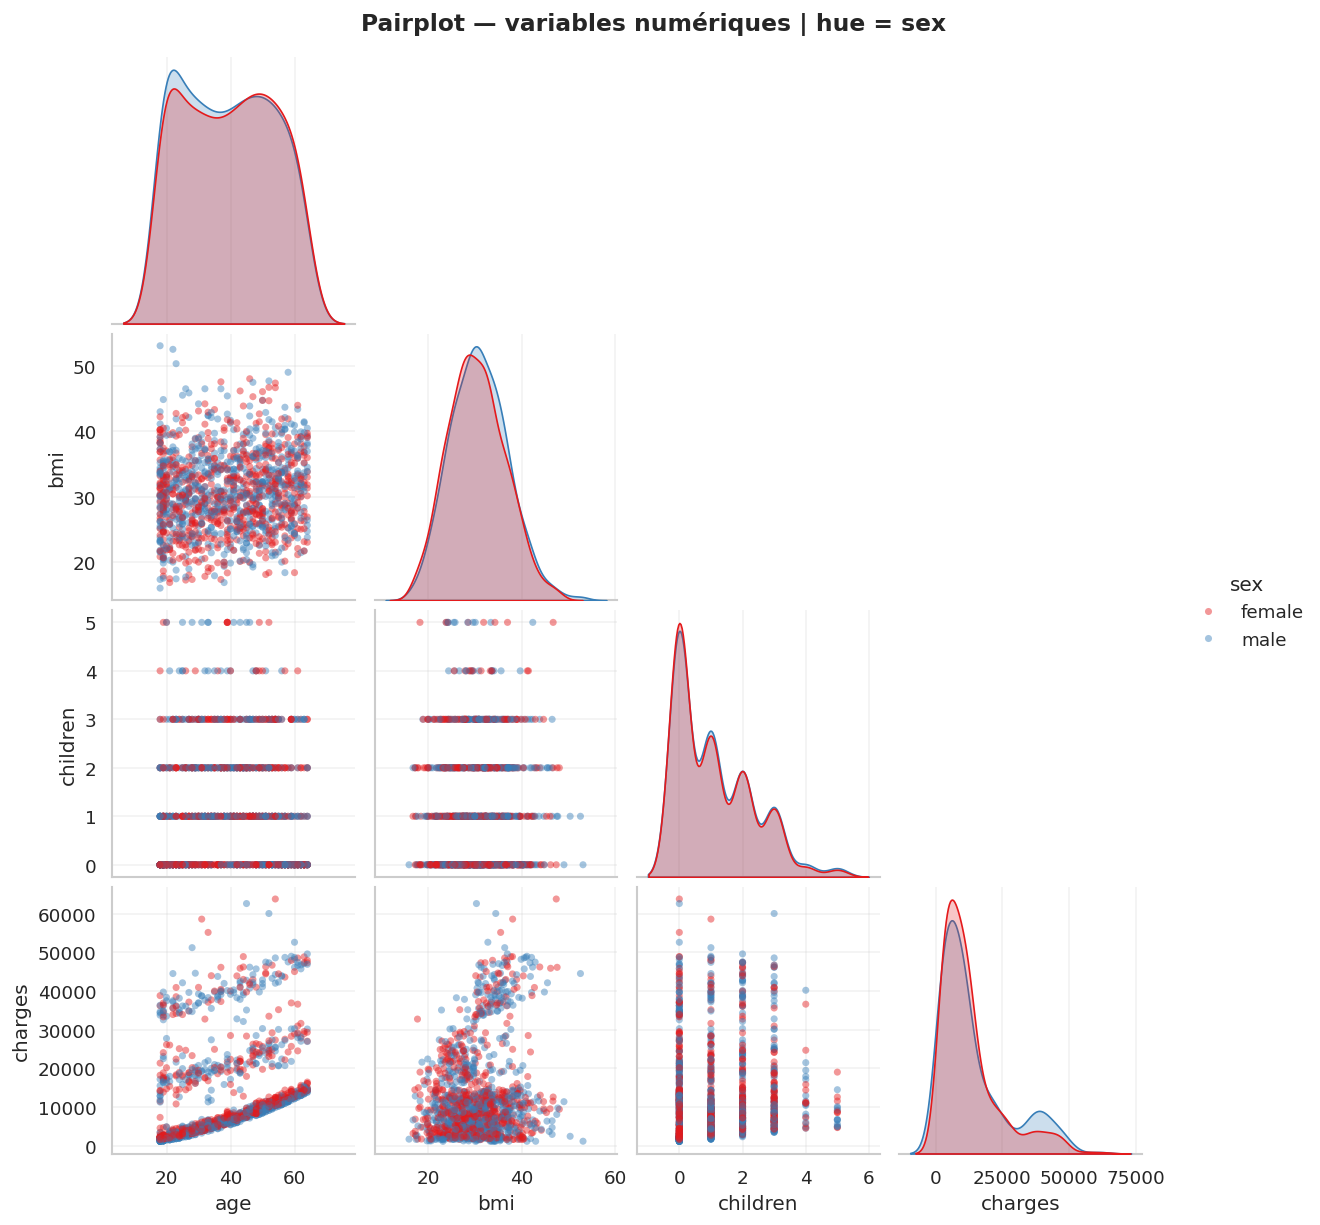

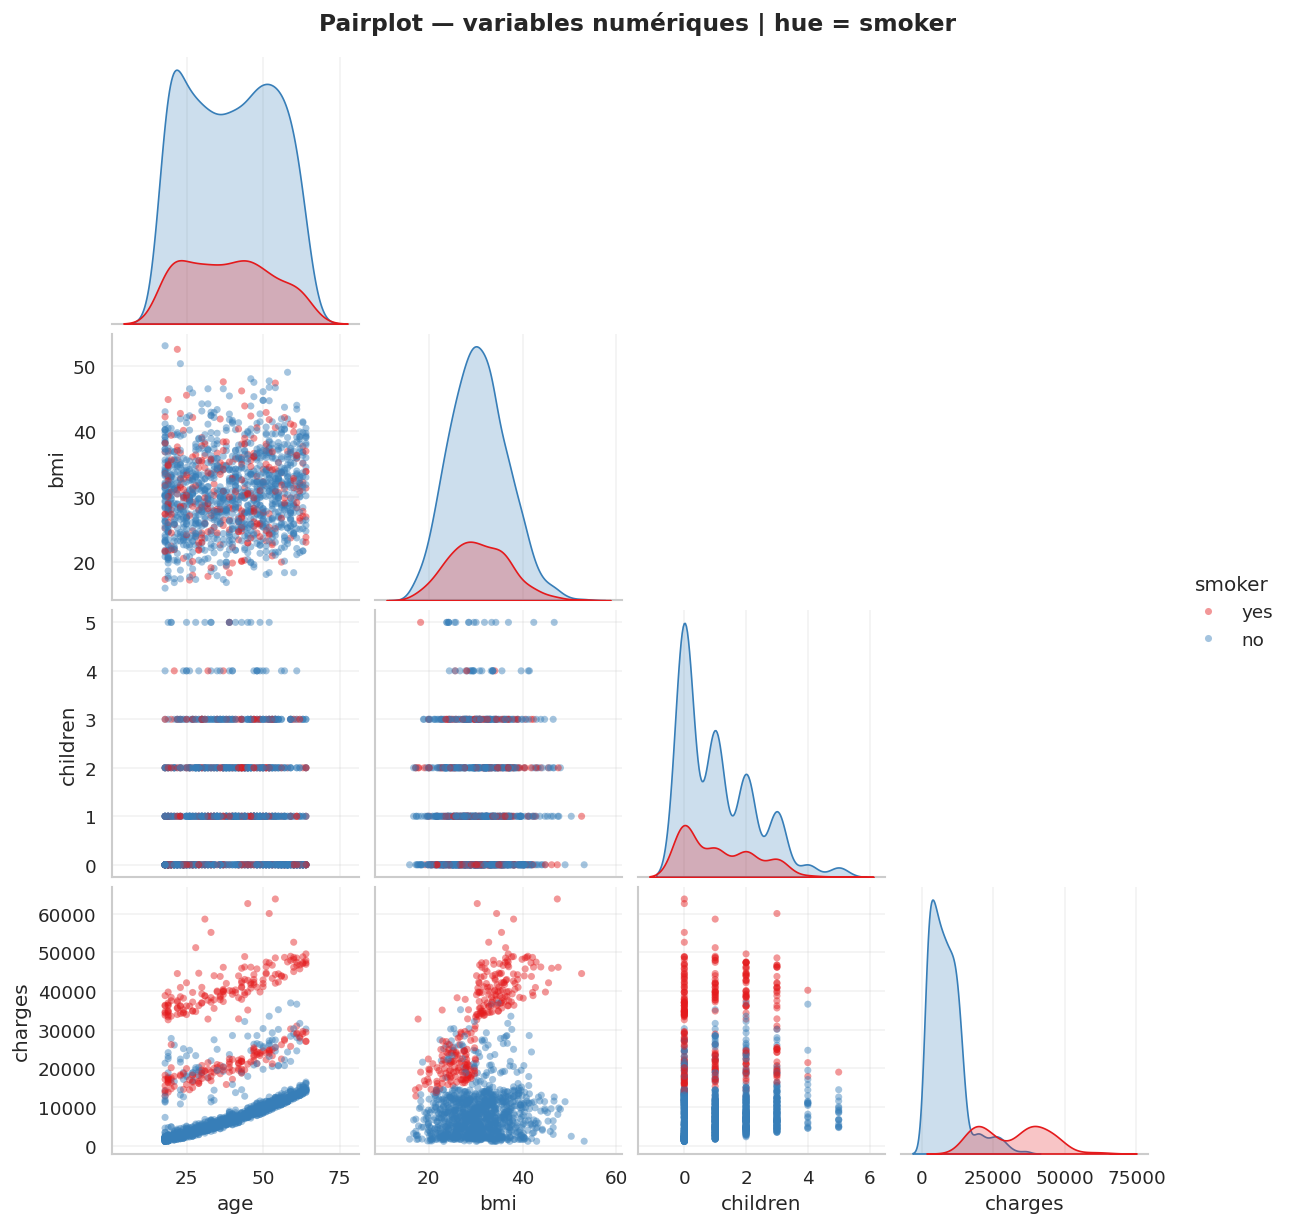

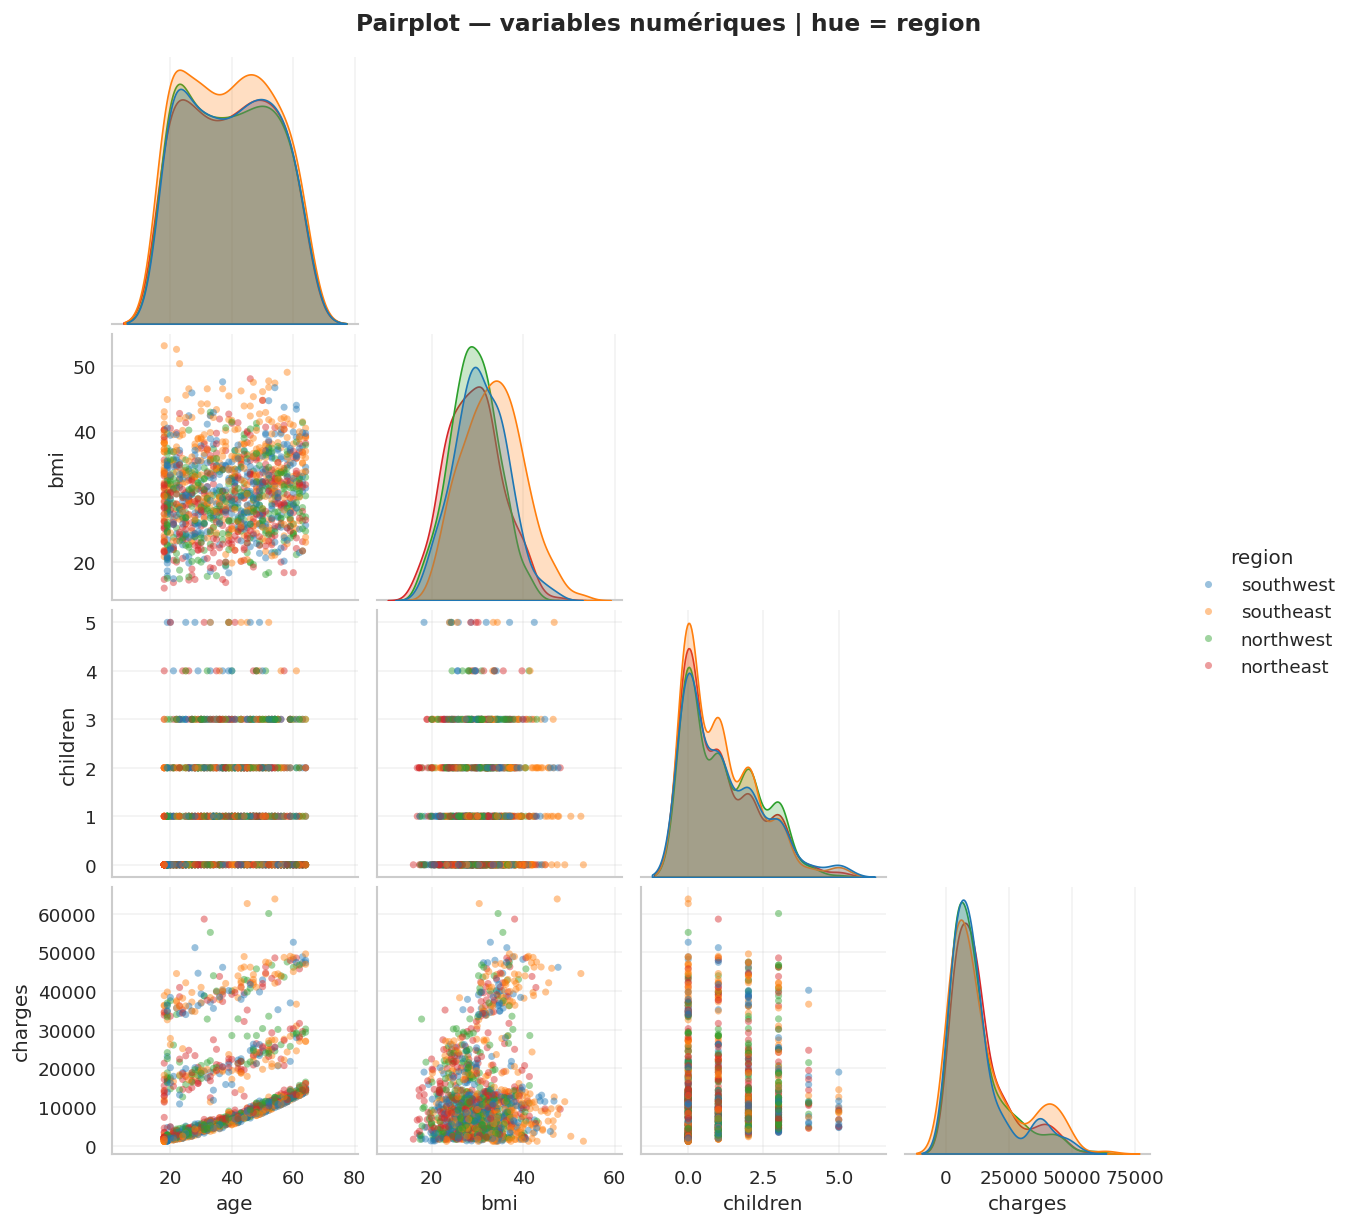

In [ ]:
 sns.set_theme(style="whitegrid")

for cat_var in categorical_vars:

    # Préparer le df pour pairplot
    cols = list(dict.fromkeys(numerical_vars + [cat_var]))  # uniques
    tmp = df[cols].copy()

    # Palette : tab10 si plusieurs classes, Set1 si 2-3 classes
    n_classes = tmp[cat_var].nunique(dropna=False)
    palette = "Set1" if n_classes <= 3 else "tab10"

    sns.pairplot(
        tmp,
        vars=numerical_vars,
        hue=cat_var,
        palette=palette,
        corner=True,
        diag_kind="kde",
        plot_kws={"alpha": 0.45, "s": 18, "edgecolor": "none"}
    )

    plt.suptitle(f"Pairplot — variables numériques | hue = {cat_var}", y=1.02, fontsize=14, fontweight="bold")
    plt.show()



---



# Synthèse et Conclusions

--**Synthèse globale de l’analyse exploratoire des données (EDA)**

L’analyse exploratoire des données a permis d’examiner la structure générale du jeu de données, d’identifier les caractéristiques des variables explicatives et de la variable cible, ainsi que de mettre en évidence les relations statistiques et graphiques pertinentes pour la modélisation.

Les variables numériques (age, bmi, children, charges) présentent des comportements hétérogènes. Les variables age et bmi affichent des distributions quasi symétriques et proches de la normalité, avec une dispersion modérée, ce qui indique qu’elles sont directement exploitables dans les modèles de Machine Learning sans transformation spécifique. La variable children, de nature discrète, est majoritairement concentrée sur de faibles valeurs, ce qui est cohérent avec une variable de comptage et ne révèle pas d’anomalie particulière.

En revanche, la variable cible charges présente une forte asymétrie positive, une dispersion élevée et la présence de valeurs extrêmes. Cette distribution reflète une forte hétérogénéité des coûts médicaux entre individus et suggère l’existence de sous-populations distinctes, notamment entre fumeurs et non-fumeurs. Cette caractéristique rend nécessaire un traitement spécifique de la variable cible avant toute modélisation.

L’analyse bivariée entre les charges et les variables numériques montre une relation positive avec l’âge et l’IMC, bien que ces relations ne soient pas strictement linéaires. La variable children ne présente qu’un effet marginal sur le niveau des charges. Les corrélations linéaires calculées confirment ces observations, avec des coefficients modérés pour l’âge et l’IMC, et faibles pour le nombre d’enfants.

Les variables catégorielles (sex, smoker, region) ont été analysées à l’aide de statistiques descriptives, de boxplots, de diagrammes en violons et de pairplots. Ces analyses révèlent que le tabagisme est de loin le facteur le plus discriminant, avec des charges significativement plus élevées et plus dispersées chez les fumeurs. À l’inverse, le sexe et la région présentent des différences plus faibles, avec des distributions largement chevauchantes.

Les tests statistiques (ANOVA et Kruskal–Wallis) confirment ces résultats :

un effet très significatif du tabagisme sur les charges,

des effets plus limités et moins robustes pour le sexe et la région selon le test utilisé.

Dans l’ensemble, l’EDA met en évidence un jeu de données propre, cohérent et riche en information, bien adapté à une modélisation supervisée, à condition d’appliquer un preprocessing approprié.

--
**Recommandations pour le preprocessing**

Au regard des résultats de l’analyse exploratoire, les étapes de preprocessing suivantes sont recommandées :

1. Transformation de la variable cible

La variable charges devra être transformée à l’aide d’une transformation logarithmique (par exemple log(charges) ou log1p(charges)) afin de réduire l’asymétrie, limiter l’influence des valeurs extrêmes et améliorer la stabilité des modèles.

2. Encodage des variables catégorielles
Les variables sex, smoker et region seront encodées à l’aide d’un One-Hot Encoding, sans imposer de relation d’ordre artificielle entre les modalités. Une attention particulière devra être portée à la variable smoker, compte tenu de son fort pouvoir explicatif.

3. Traitement des variables numériques
Les variables age et bmi pourront être utilisées directement, tandis que children pourra être conservée comme variable numérique discrète ou éventuellement regroupée en classes selon le modèle utilisé.

4. Mise à l’échelle des variables
Une standardisation des variables numériques est recommandée pour les modèles sensibles à l’échelle (régressions régularisées, SVR, KNN, réseaux de neurones). Les modèles arborescents ne nécessitent pas de mise à l’échelle.

5. Gestion des valeurs extrêmes
Les valeurs extrêmes de la variable charges ne devront pas être supprimées, car elles reflètent des situations économiques réelles. Leur impact sera atténué par la transformation logarithmique et par le choix de modèles robustes.

6. Pipeline et reproductibilité
L’ensemble des étapes de preprocessing devra être intégré dans un pipeline afin de garantir la reproductibilité des résultats et d’éviter toute fuite d’information entre les ensembles d’entraînement et de test.



---


<center><h1 style="font-size:35px; font-family: 'Calisto MT'; letter-spacing: 0.1em; background-color: RGB(128,0,128);">  </h1></center>
<center><h1 style="font-size:25px; font-family: 'Calisto MT'; letter-spacing: 0.1em; background-color: RGB(51,165,182);">Fin de l'EDA </h1></center>



---

